In [34]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas

In [35]:
seed = 7
np.random.seed(seed)


NepoLF = 3000  # number of epochs for first NN: NN_LF
NepoLin = 1500  # number of epochs for second NN: NN_Lin
NepoHF = 3000  # number of epochs for second NN: NN_HF

########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF.mat"
(reaction_LF,x_LF,y_LF, U_LF) = import_data(file_path_LF)
#reaction_LF = np.column_stack((reaction_LF, x_LF, y_LF))
reaction_LF_test = reaction_LF
x_LF_test = x_LF
y_LF_test = y_LF

U_LF_test = U_LF
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF,x_HF,y_HF, U_HF) = import_data(file_path_HF)
#reaction_HF = np.column_stack((reaction_HF, x_HF, y_HF))
reaction_HF_test = reaction_HF
x_HF_test = x_HF
y_HF_test = y_HF
U_HF_test = U_HF

In [36]:
from itertools import product

# Tre vettori di esempio
vettore1 = [1, 2]
vettore2 = ['a', 'b']
vettore3 = [10, 20]

# Calcola tutte le combinazioni di elementi unendo i tre vettori
combinazioni = np.array(list(product(vettore1, vettore2, vettore3)))

# Stampa l'array di combinazioni
print(combinazioni)

[['1' 'a' '10']
 ['1' 'a' '20']
 ['1' 'b' '10']
 ['1' 'b' '20']
 ['2' 'a' '10']
 ['2' 'a' '20']
 ['2' 'b' '10']
 ['2' 'b' '20']]


In [37]:
#########################     TRAIN SET      ##########################

permutation_r = np.random.permutation(len(reaction_LF))
Nlf = 15
reaction_LF = reaction_LF[permutation_r][0:Nlf,:]

permutation_x = np.random.permutation(len(x_LF))
x_LF = x_LF[permutation_x][0:Nlf,:]

permutation_y = np.random.permutation(len(y_LF))
y_LF = y_LF[permutation_y][0:Nlf,:]

########################     NORMALIZATION  #########################
# Output
# We consider the central value of U
U_LF = U_LF[
    permutation_r,
    int(np.shape(U_LF)[1] / 2) - 1,
    :,:
]
U_LF=U_LF[:,permutation_x,:]
U_LF=U_LF[:,:,permutation_y]
U_LF=U_LF[0:Nlf,0:Nlf,0:Nlf].diagonal().diagonal()
reaction_LF = np.column_stack((reaction_LF, x_LF, y_LF))
reaction_LF_test=np.array(list(product(reaction_LF_test, x_LF_test, y_LF_test)))
U_LF_test = U_LF_test[
    :,
    int(np.shape(U_LF_test)[1] / 2) - 1,
    :,
    :
].ravel()

# Input
reaction_max = np.max(reaction_LF_test)
reaction_min = np.min(reaction_LF_test)

# reaction_test_norm = (reaction_test - reaction_min) / (reaction_max - reaction_min)
reaction_LF = (reaction_LF - reaction_min) / (reaction_max - reaction_min)
reaction_LF_test = (reaction_LF_test - reaction_min) / (
    reaction_max - reaction_min
)

# HF
permutation_r = np.random.permutation(len(reaction_HF))
Nhf = 10
reaction_HF = reaction_HF[permutation_r][0:Nhf]

permutation_x = np.random.permutation(len(x_HF))
x_HF = x_HF[permutation_x][0:Nhf,:]

permutation_y = np.random.permutation(len(y_HF))
y_HF = y_HF[permutation_y][0:Nhf,:]

reaction_HF = np.column_stack((reaction_HF, x_HF, y_HF))

reaction_HF = (reaction_HF - reaction_min) / (reaction_max - reaction_min)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

U_HF = U_HF[
    permutation_r,
    int(np.shape(U_HF)[1] / 2) - 1,
    :,:
]
U_HF=U_HF[:,permutation_x,:]
U_HF=U_HF[:,:,permutation_y]
U_HF=U_HF[0:Nhf,0:Nhf,0:Nhf].diagonal().diagonal()

U_HF_test = U_HF_test[
    :, -1, :,:
].ravel()
reaction_HF_test=np.array(list(product(reaction_HF_test, x_HF_test, y_HF_test)))



# TRANSFORMATION 

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
U_t_max_test = np.max(U_LF_test)
U_t_min_test = np.min(U_LF_test)

U_LF = (U_LF - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

In [38]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # where do they come from

modelLF = getModel(bestLF_params, "LF")
histLF = modelLF.fit(
    reaction_LF, U_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
)
print("LF NN done")

ULF = modelLF.predict(reaction_LF_test)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r_2}")

LF NN done
800/800 [==============================] - 1s 1ms/step

LF Model:
Test MSE: 0.2642528709475727
R^2: -1.385915709146352


800/800 [==============================] - 1s 1ms/step


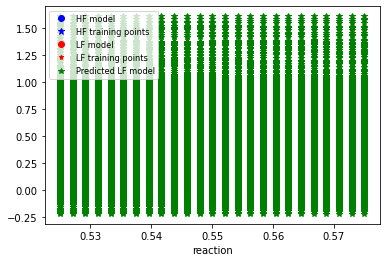

ValueError: x and y can be no greater than 2D, but have shapes (25600, 3, 1) and (25600,)

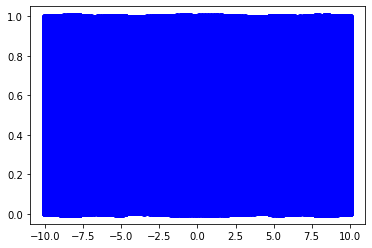

In [39]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "bo", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[:,0],
    U_HF,
    "b*",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[:,0], U_LF_test, "ro", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "r*",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_LF_test[:,0],
    modelLF.predict(reaction_LF_test),
    "g*",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.xlabel("reaction")
plt.show()

plt.figure()
plt.plot(reaction_HF_test[:,1], U_HF_test, "bo", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[:,1],
    U_HF,
    "b*",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test, U_LF_test, "ro", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,1],
    U_LF,
    "r*",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_LF_test[:,1],
    modelLF.predict(reaction_LF_test),
    "g*",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.xlabel("x")
plt.show()

plt.figure()
plt.plot(reaction_HF_test[:,2], U_HF_test, "bo", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[:,2],
    U_HF,
    "b*",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[:,2], U_LF_test, "ro", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,2],
    U_LF,
    "r*",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_LF_test[:,2],
    modelLF.predict(reaction_LF_test),
    "g*",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.xlabel("y")
plt.show()

print(f"\n-------  #HF data = {Nhf}  -------")
start = perf_counter()

In [51]:
##########################    SECOND NN: NN_Lin    ##########################
reaction_test_help = modelLF.predict(reaction_LF_test)[:, 0]
reaction_test_help=np.resize(reaction_test_help,(np.shape(reaction_test_help)[0],1))
reaction_test_in = np.concatenate(
    (reaction_LF_test[:,:,0],reaction_test_help),axis=1
)  # <- TEST INPUT for the second NN: NN_HF

reaction_train_help = modelLF.predict(reaction_HF)  # f_LF(mu_hf_train)
reaction_lin = np.concatenate(
    (reaction_HF, reaction_train_help),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

bestLin_params = {
    "lr": 0.001,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
    "l2weight": 0.01,
}
modelLin = getModel(bestLin_params, "Hflin")
histLin = modelLin.fit(
    reaction_lin,
    U_HF,
    validation_data=(reaction_test_in, U_HF_test),
    epochs=NepoLin,
    batch_size=Nhf,
    verbose=0,
    validation_freq=50,
)

ULin = modelLin.predict(
    np.concatenate((reaction_LF_test[:,:, 0], np.resize(reaction_test_help,(np.shape(reaction_test_help)[0],1)))
))

##########################    THIRD NN: NN_HF    ##########################
# Input for training NN_HF
reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
reaction_final = np.vstack(
    (reaction_HF.transpose(), reaction_train_help, reaction_help1)
).transpose()

# Input for testing NN_HF
reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
reaction_test_final = np.vstack(
    (reaction_LF_test.transpose(), reaction_test_help, reaction_test_help1)
).transpose()

name = "3step"


 35/800 [>.............................] - ETA: 2s

1/1 [==============================] - 0s 16ms/step


ValueError: Data cardinality is ambiguous:
  x sizes: 25600
  y sizes: 250000
Make sure all arrays contain the same number of samples.

In [55]:
print(np.shape(reaction_LF_test[:,:,0]))
print(np.shape(reaction_LF_test))


(25600, 3)
(25600, 3, 1)


In [41]:
print(np.shape(reaction_LF_test[:,:,0]))
reaction_test_help=np.resize(reaction_test_help,(np.shape(reaction_test_help)[0],1))

#print(np.shape([reaction_test_help].transpose()))
#reaction_test_help.resize(np.shape(reaction_test_help),1)
np.concatenate((reaction_LF_test[:,:,0],reaction_test_help),axis=1)

(25600, 3)


array([[0.525     , 0.        , 0.        , 0.51091075],
       [0.525     , 0.        , 0.03225806, 0.76031268],
       [0.525     , 0.        , 0.06451613, 1.0612222 ],
       ...,
       [0.575     , 1.        , 0.93548387, 1.0596149 ],
       [0.575     , 1.        , 0.96774194, 1.05322099],
       [0.575     , 1.        , 1.        , 1.04302907]])

In [ ]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 15

K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(Nhf, NepoHF, reaction_final, U_HF, params, name)
    return {"loss": CVres, "params": params, "status": STATUS_OK}


# The following call will optimize and select the best parameters:
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)

####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(best_params, name)
hist = finalModel.fit(
    reaction_final,
    U_HF,
    validation_data=(reaction_test_final, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_test_final)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

# print("Number of base functions: ", int(Nlf_models[m]))
# print("Number of HF data: ", n_HF)

U_Lin = modelLin.predict(
    np.vstack((reaction_LF_test, reaction_test_help)).transpose()
)

  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

job exception: name 'reaction_final' is not defined



  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]


NameError: name 'reaction_final' is not defined

In [ ]:
####################    HF GRAPHS    #######################
plt.figure()
plt.plot(
    reaction_HF_test[:,0],
    UHF,
    "ko",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)
plt.plot(reaction_HF_test[:,0], U_Lin, "go", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[:,0],
    modelLF.predict(reaction_HF_test),
    "bo",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[:,0], U_HF, "ro", label="HF data")
plt.plot(reaction_HF_test[:,0], U_HF_test, "yo", label="exact solution")
plt.title("High fidelity model [reaction] ")
plt.legend(prop={"size": 8})

plt.figure()
plt.plot(
    reaction_HF_test[:,1],
    UHF,
    "ko",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)
plt.plot(reaction_HF_test[:,1], U_Lin, "go", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[:,1],
    modelLF.predict(reaction_HF_test),
    "bo",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[:,1], U_HF, "ro", label="HF data")
plt.plot(reaction_HF_test[:,1], U_HF_test, "yo", label="exact solution")
plt.title("High fidelity model [x] ")
plt.legend(prop={"size": 8})

plt.figure()
plt.plot(
    reaction_HF_test[:,2],
    UHF,
    "ko",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)
plt.plot(reaction_HF_test[:,2], U_Lin, "go", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[:,2],
    modelLF.predict(reaction_HF_test),
    "bo",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[:,2], U_HF, "ro", label="HF data")
plt.plot(reaction_HF_test[:,2], U_HF_test, "yo", label="exact solution")
plt.title("High fidelity model [y] ")
plt.legend(prop={"size": 8})


In [ ]:
####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(hist.history["mse"], color="red", label="High fidelity train mse")
plt.plot(histLin.history["mse"], color="green", label="high fidelity lin")
plt.plot(histLF.history["mse"], color="black", label="Low fidelity")
plt.legend()
plt.yscale("log")
plt.subplot(2, 1, 2)
plt.plot(hist.history["val_mse"], color="red")
plt.plot(histLin.history["val_mse"], color="green")
plt.yscale("log")

In [ ]:
print(np.shape(U_LF))
print(np.shape(reaction_LF))

(25, 1601, 32, 32)
(25, 1)


In [ ]:
print(np.shape(x_HF))
print(np.shape(x_LF))

(100, 1)
(32, 1)
